In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [219]:
data = pd.read_csv("housing.csv")
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [221]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [222]:
# we just removed those rows as total little over 20k row and only 200 rows were have nan values
data.dropna(inplace=True)  # inplace to apply this change

In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [224]:
from sklearn.model_selection import train_test_split

# basically mdeican house 
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [225]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # we leave 20% of the data for evaluating our model
# 80% of the data is used for training

In [226]:
train_data = X_train.join(y_train)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
17821,-121.88,37.37,14.0,6016.0,1404.0,3258.0,1316.0,3.5745,<1H OCEAN,333700.0
10081,-120.23,39.36,7.0,2045.0,358.0,245.0,92.0,4.0481,INLAND,152300.0
6931,-118.08,34.01,33.0,1091.0,233.0,890.0,226.0,2.7679,<1H OCEAN,176400.0
18969,-122.02,38.26,20.0,3899.0,763.0,2198.0,779.0,3.2061,INLAND,120400.0
18034,-121.93,37.24,26.0,2574.0,414.0,1096.0,428.0,6.0738,<1H OCEAN,335900.0
...,...,...,...,...,...,...,...,...,...,...
6598,-118.16,34.18,48.0,568.0,145.0,559.0,135.0,2.4135,<1H OCEAN,135700.0
492,-122.25,37.86,52.0,1587.0,444.0,878.0,449.0,1.7652,NEAR BAY,336800.0
9661,-120.87,41.54,21.0,1091.0,208.0,660.0,188.0,2.2321,INLAND,34600.0
9923,-122.31,38.32,35.0,3997.0,762.0,2074.0,703.0,3.2850,NEAR BAY,138100.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

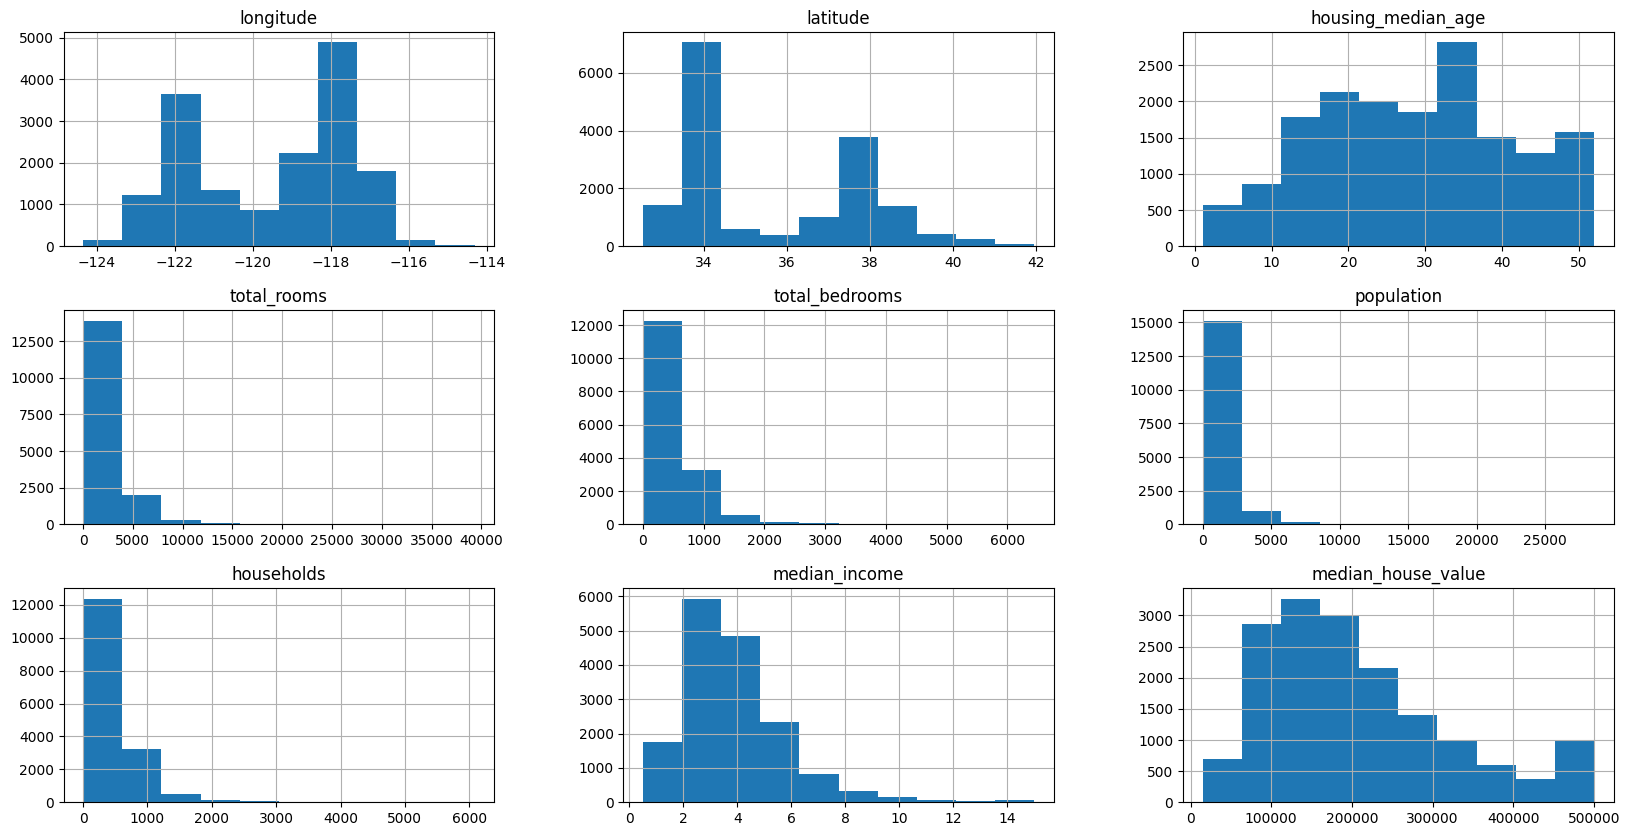

In [227]:
train_data.hist(figsize=(20,10))

<Axes: >

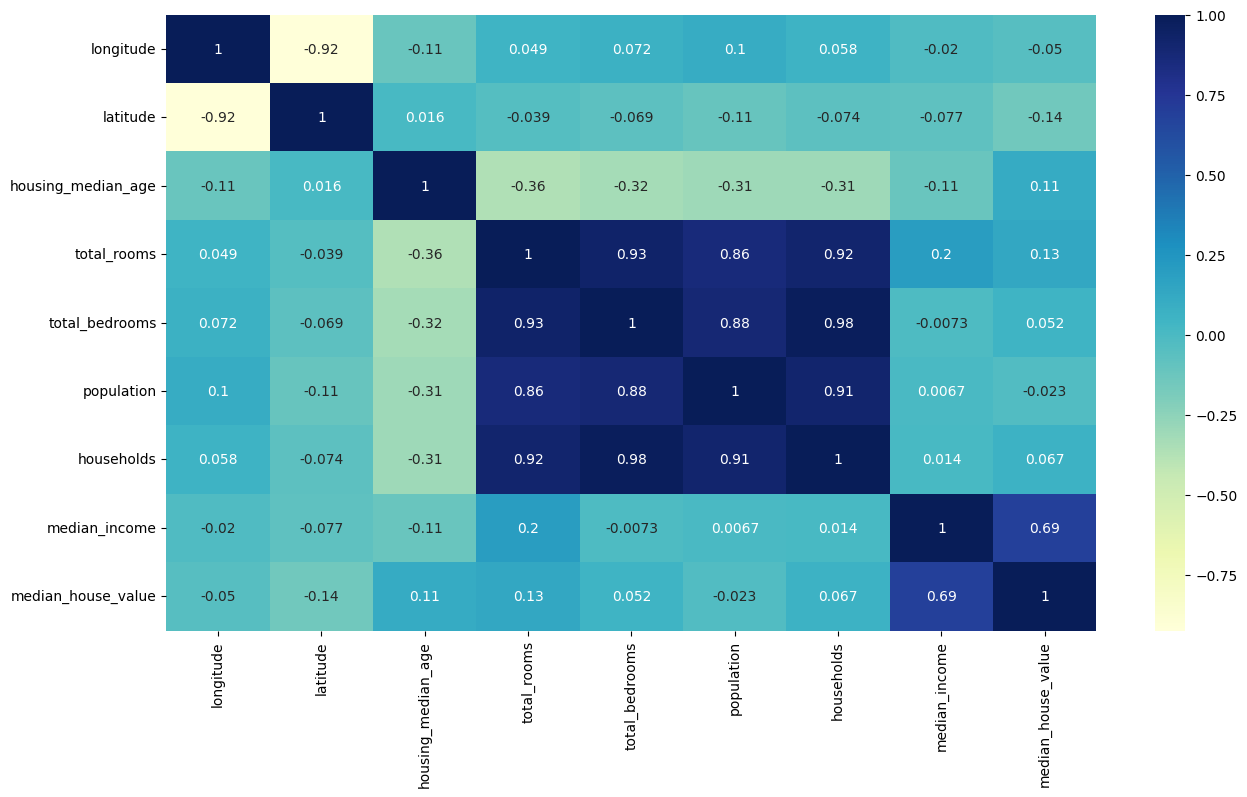

In [228]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [229]:
# we see from the histogram some values were right skewed
# for the skewed values as visible from the histogram graph we do its log and add +1 to prevent 0 values inside log
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

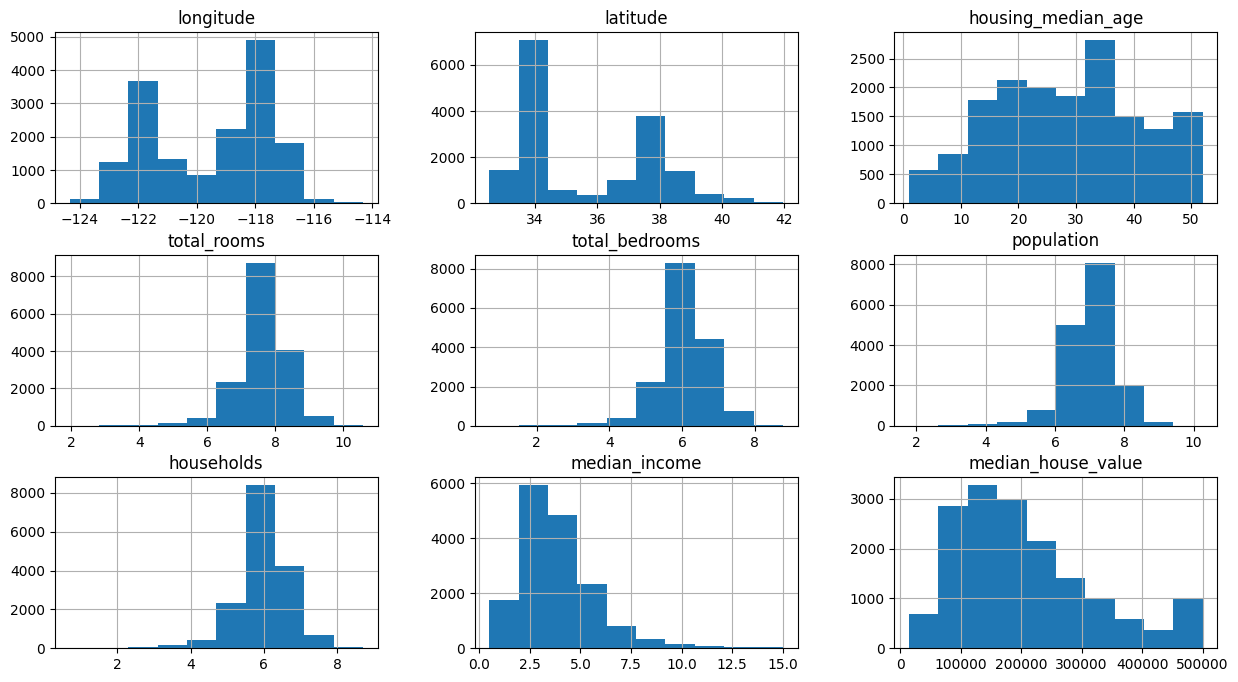

In [230]:
train_data.hist(figsize=(15,8))

In [231]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7132
INLAND        5261
NEAR OCEAN    2126
NEAR BAY      1823
ISLAND           4
Name: count, dtype: int64

In [232]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity).astype(int)).drop(['ocean_proximity'],axis=1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
17821,-121.88,37.37,14.0,8.702344,7.247793,8.089176,7.183112,3.5745,333700.0,1,0,0,0,0
10081,-120.23,39.36,7.0,7.623642,5.883322,5.505332,4.532599,4.0481,152300.0,0,1,0,0,0
6931,-118.08,34.01,33.0,6.995766,5.455321,6.792344,5.424950,2.7679,176400.0,1,0,0,0,0
18969,-122.02,38.26,20.0,8.268732,6.638568,7.695758,6.659294,3.2061,120400.0,0,1,0,0,0
18034,-121.93,37.24,26.0,7.853605,6.028279,7.000334,6.061457,6.0738,335900.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6598,-118.16,34.18,48.0,6.343880,4.983607,6.327937,4.912655,2.4135,135700.0,1,0,0,0,0
492,-122.25,37.86,52.0,7.370231,6.098074,6.778785,6.109248,1.7652,336800.0,0,0,0,1,0
9661,-120.87,41.54,21.0,6.995766,5.342334,6.493754,5.241747,2.2321,34600.0,0,1,0,0,0
9923,-122.31,38.32,35.0,8.293550,6.637258,7.637716,6.556778,3.2850,138100.0,0,0,0,1,0


<Axes: >

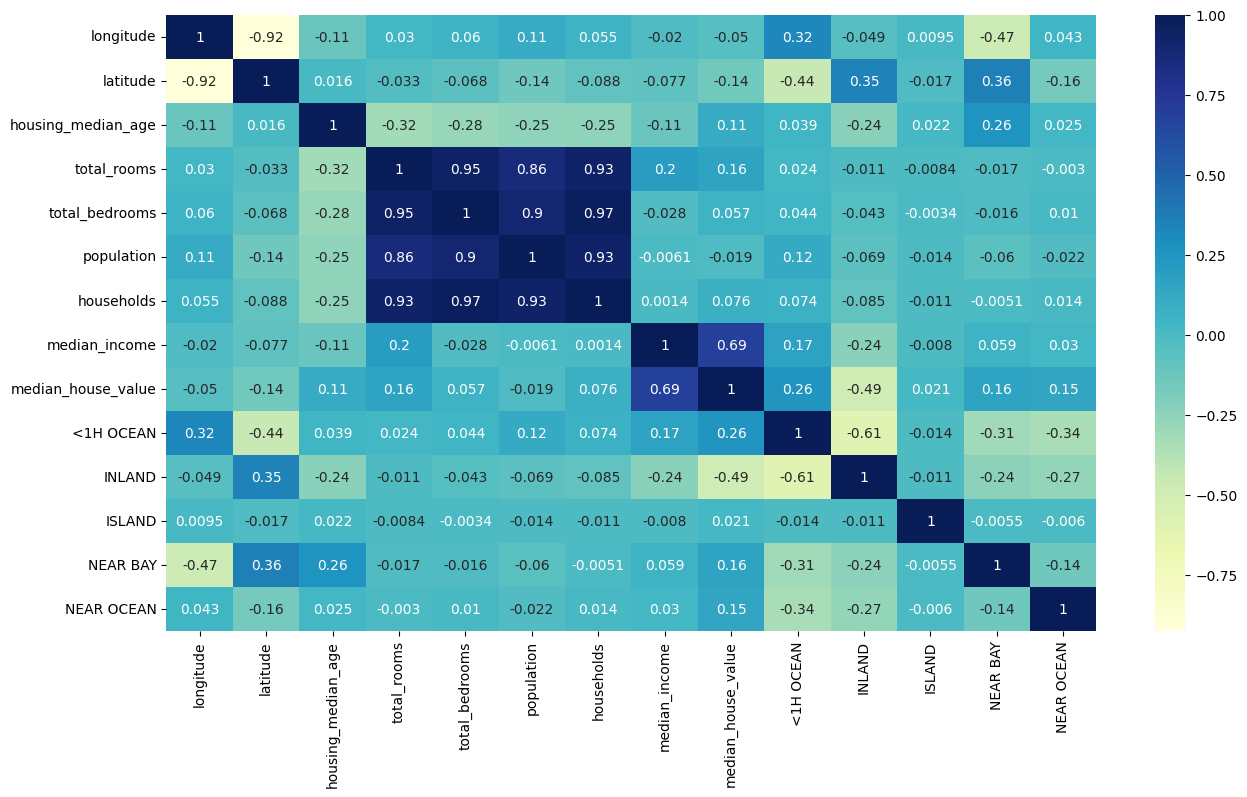

In [233]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

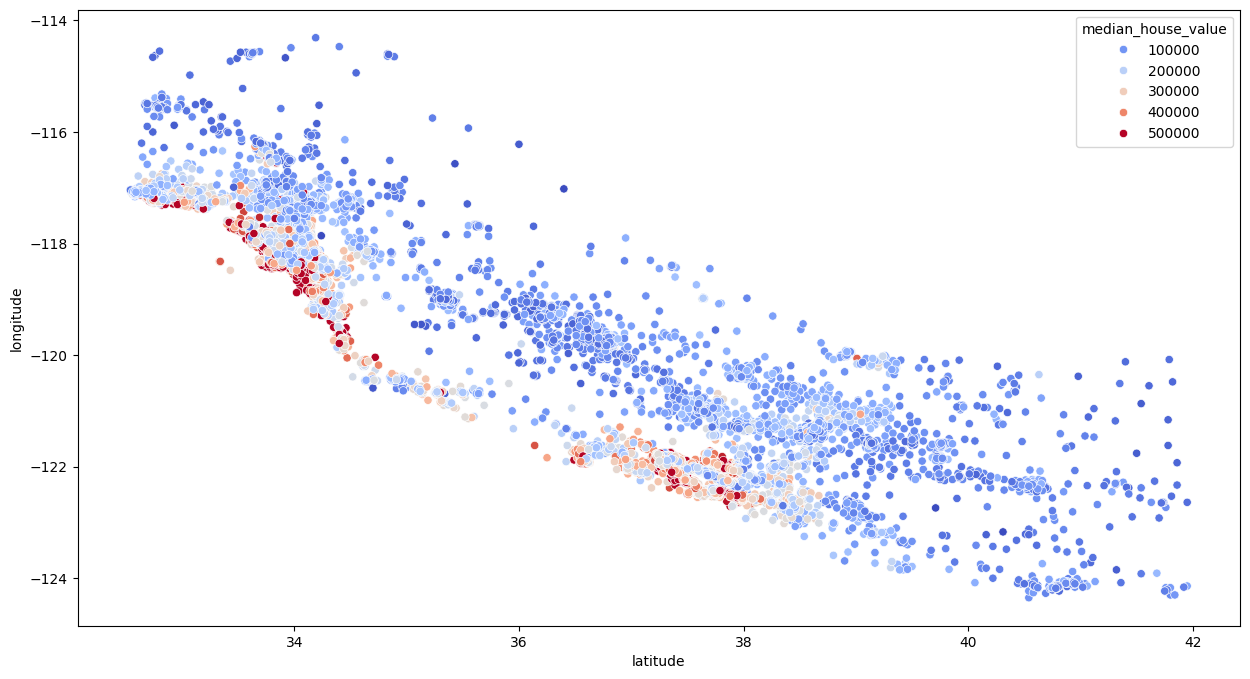

In [234]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude', y='longitude', data=train_data, hue="median_house_value", palette='coolwarm')

In [235]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']
# in this dataset the totol rooms and bedrooms are should for the block not each house

<Axes: >

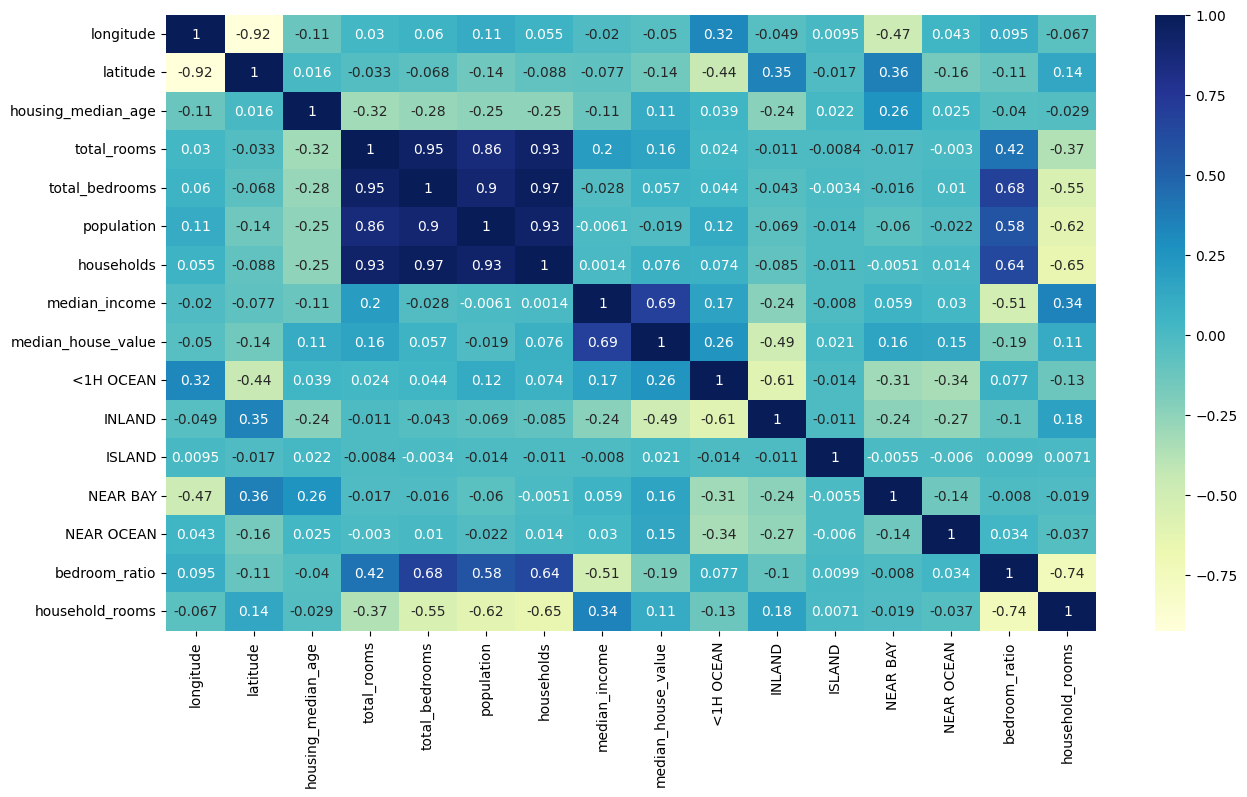

In [236]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [237]:
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']


X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()

# reg.fit(X_train, y_train)
reg.fit(X_train_s, y_train)

LinearRegression()

In [238]:
# we take the test data and do all the things we did with the training data 

test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity).astype(int)).drop(['ocean_proximity'],axis=1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

X_test, y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']

X_test_s = scaler.transform(X_test)

# test_data
# if column is missing from the test and train data which could happen that column could be missing if all 0 so add that

In [239]:
# reg.score(X_test, y_test)
# this is the score we would get better score in the random forest model

reg.score(X_test_s, y_test)

# basically in this case scaling the data did not really imporve the result just usually we should scale the data

# Most of the time, only X is scaled, because ML models handle Y naturally in its original scale


0.671848171218611

In [240]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

# forest.fit(X_train, y_train)
forest.fit(X_train_s, y_train)

RandomForestRegressor()

In [241]:
# forest.score(X_test, y_test)
forest.score(X_test_s, y_test)

# again not much difference in using scaled vs not scale version

0.8133408038857577

In [242]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor() # this is to get a fresh untrained model again

param_grid = {
    "n_estimators" : [100, 200, 300],
    # "max_features" : [6,8, 10,12], # we commented it as not super useful not much helping this case so removed to make faster
    "min_samples_split" : [2, 4],
    "max_depth" : [None, 4, 8]
}
# putting too much values will case it slower as it checks each one

grid_search = GridSearchCV(forest, param_grid, cv= 5, scoring = "neg_mean_squared_error", return_train_score=True)
# we did neg-mse as the bigger the values the better mse will be the lower the better

grid_search.fit(X_train_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_split': [2, 4],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [243]:
best_forest = grid_search.best_estimator_ # we save the best parameters
print(best_forest)

RandomForestRegressor(n_estimators=300)


In [244]:
best_forest.score(X_test_s, y_test)
# in this case we get a worse performance with hyperparameter tuning and cross verification but usually its better

# another thing we can do is see the best parameters then change the values in parameter grid nearer to them

# for example 3, 4, 50, 60 is n_estimators and best is 60 then go 60 , 70 ... like from that to higher

# if the best_estimator is not showing a value means it took default
# default for n_estimator is 100, min_sample_split is 2, max_depth is None

0.8146592043270784